C:\Users\veerk\AppData\Local\Temp\ipykernel_28516\3895056998.py:287: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
c:\Users\veerk\OneDrive\Desktop\DIP Project\dip\Lib\site-packages\torch\amp\grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


Starting training on cpu for 10 epochs...


Epoch 1/10 (Train):   0%|          | 0/446 [00:00<?, ?it/s]c:\Users\veerk\OneDrive\Desktop\DIP Project\dip\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\veerk\AppData\Local\Temp\ipykernel_28516\3895056998.py:313: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\veerk\OneDrive\Desktop\DIP Project\dip\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch 1/10 (Train): 100%|██████████| 446/446 [36:41<00:00,  4.94s/it] 
C:\Users\veerk\AppData\Local\Temp\ipykernel_28516\3895056998.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  w

Epoch 1 finished. Train Loss: 0.2717 | Val Loss: 0.1144 | Val mIoU: 0.8910
Model saved!


Epoch 2/10 (Train): 100%|██████████| 446/446 [30:51<00:00,  4.15s/it]  


...

Epoch 8 finished. Train Loss: 0.1120 | Val Loss: 0.0955 | Val mIoU: 0.8903


Epoch 9/10 (Train): 100%|██████████| 446/446 [20:23<00:00,  2.74s/it]


Epoch 9 finished. Train Loss: 0.1097 | Val Loss: 0.0887 | Val mIoU: 0.9088


Epoch 10/10 (Train): 100%|██████████| 446/446 [20:09<00:00,  2.71s/it]


Epoch 10 finished. Train Loss: 0.1041 | Val Loss: 0.0946 | Val mIoU: 0.9002

--- Loading best model for final evaluation and visualization ---

--- Generating Visualizations ---


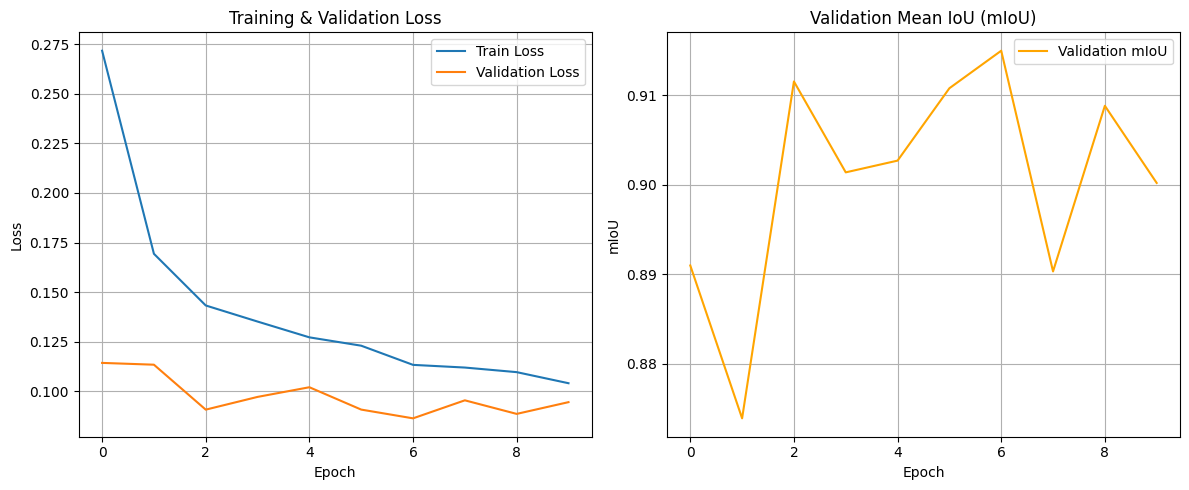

Generated: Training and Validation Curves


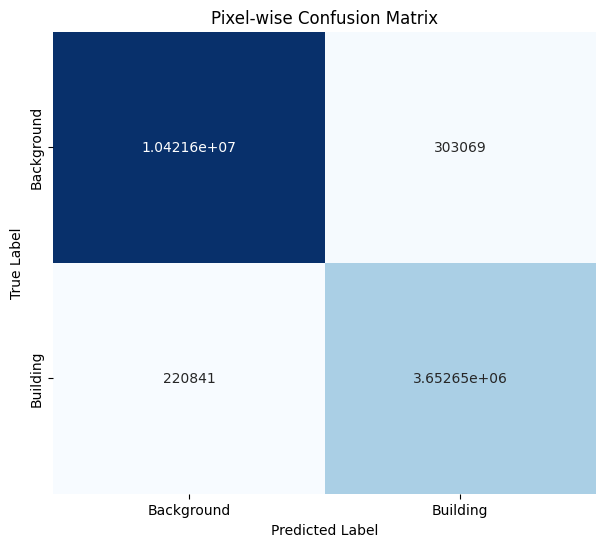

Generated: Confusion Matrix

--- Quantitative Metrics Summary (on Validation Set) ---
Overall Pixel Accuracy: 0.9641
Overall IoU (Jaccard Index): 0.8746
Building Class Precision: 0.9234
Building Class Recall: 0.9430
Building Class F1-Score: 0.9331


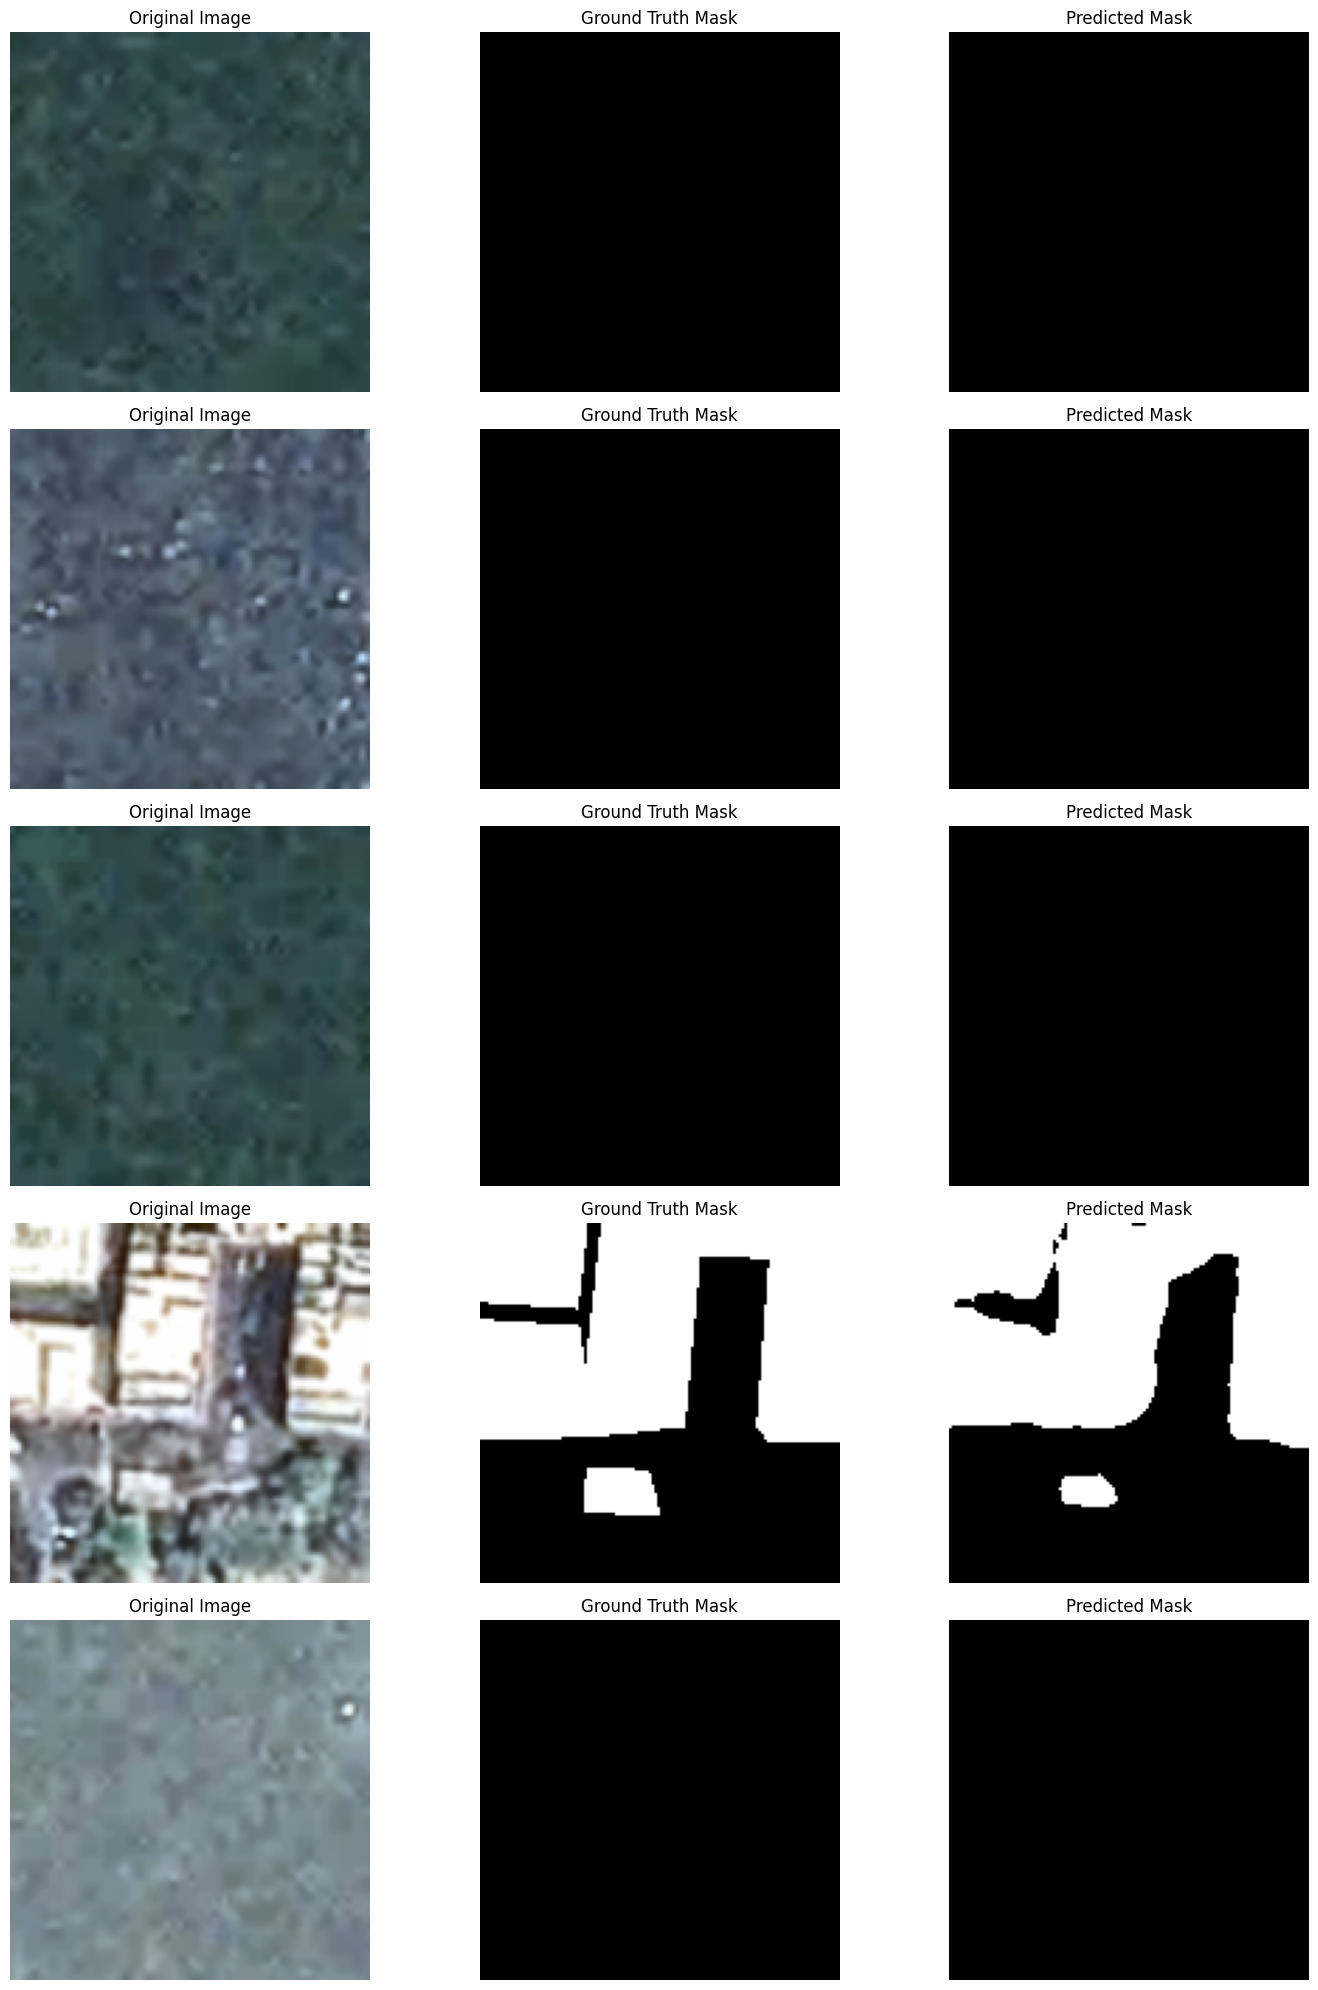

Generated: 5 Visual Segmentation Examples

--- Starting Optional Final Inference and Post-processing ---


In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import cv2
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, jaccard_score, precision_score, recall_score, f1_score, accuracy_score

# Geoprocessing libraries for final output
import rasterio.features
from shapely.geometry import shape

# Import utilities from the other files
from data_utils import SegmentationDataset, enhance_image_dip
from model_utils import get_model, combined_loss, iou_score # Assuming iou_score handles logits -> binary mask implicitly

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
NUM_EPOCHS = 10
LR = 1e-4
IMAGE_SIZE = 128 # Define image size for consistency

# --- Data Path Placeholders ---
BASE_PATH = "../Dataset/Prepared_Dataset"
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MASK_DIR = os.path.join(BASE_PATH, "train/masks")
VAL_IMG_DIR = os.path.join(BASE_PATH, "val/images")
VAL_MASK_DIR = os.path.join(BASE_PATH, "val/masks")


# --- Augmentations ---
train_transform = A.Compose([
    A.RandomRotate90(),
    A.HorizontalFlip(),
    A.VerticalFlip(),
    A.Affine(rotate=(-15,15), scale=(0.9,1.1), translate_percent=(0.06,0.06)),
    A.RandomBrightnessContrast(p=0.5),
    A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# --- Validation Function (Modified to return predictions for metrics) ---
def validate_epoch(model, val_loader):
    model.eval()
    val_loss_sum = 0.0
    val_miou_sum = 0.0
    all_preds = []
    all_masks = []
    
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE).squeeze(3).unsqueeze(1) # [B, 1, H, W]

            with torch.cuda.amp.autocast():
                logits = model(imgs) # Logits [B, 1, H, W]
                loss = combined_loss(logits, masks)
            
            val_loss_sum += loss.item() * imgs.size(0)
            val_miou_sum += iou_score(logits, masks) * imgs.size(0)

            # Binarize logits to get predictions for confusion matrix
            preds = (torch.sigmoid(logits) > 0.5).long() # Assuming binary segmentation
            
            all_preds.append(preds.cpu().numpy())
            all_masks.append(masks.cpu().numpy())

    avg_loss = val_loss_sum / len(val_loader.dataset)
    avg_miou = val_miou_sum / len(val_loader.dataset)
    
    # Concatenate all predictions and masks
    all_preds = np.concatenate(all_preds, axis=0) # Shape [N, 1, H, W]
    all_masks = np.concatenate(all_masks, axis=0) # Shape [N, 1, H, W]
    
    return avg_loss, avg_miou, all_preds, all_masks


# --- DIP Post-Processing and Vectorization (Keep as is) ---
def post_process_mask_dip(raw_prediction_mask, min_area_threshold=50):
    """
    Applies morphological closing and small object removal to the binary mask.
    Inputs: binary mask (H, W) of type np.uint8 (0 or 255)
    Outputs: cleaned binary mask (H, W)
    """
    if raw_prediction_mask.max() <= 1:
        raw_prediction_mask = raw_prediction_mask * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed_mask = cv2.morphologyEx(raw_prediction_mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed_mask, 4, cv2.CV_32S)
    final_mask = np.zeros_like(closed_mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area_threshold:
            final_mask[labels == i] = 255

    return final_mask.astype(np.uint8)


def mask_to_polygons(final_mask, transform=None):
    """
    Converts a cleaned raster mask into Shapely vector polygons.
    """
    polygons = []
    for geom, value in rasterio.features.shapes(final_mask.astype(np.int16), mask=final_mask, transform=transform):
        if value > 0:
            polygons.append(shape(geom))
    return polygons

# --- Sliding Window Inference Sketch (Keep as is) ---
def sliding_window_predict(large_image_path, model, tile_size=120, overlap_ratio=0.5):
    print("--- Running Sliding Window Inference Sketch ---")

    img = cv2.imread(large_image_path)
    img_enhanced = enhance_image_dip(img)

    H, W, _ = img.shape
    step = int(tile_size * (1 - overlap_ratio))

    full_logit_map = np.zeros((H, W), dtype=np.float32)
    hit_count = np.zeros((H, W), dtype=np.uint8)

    full_logit_map = np.random.rand(H, W) * 5 - 2
    prob_map = 1 / (1 + np.exp(-full_logit_map))
    raw_mask = (prob_map > 0.5).astype(np.uint8) * 255

    cleaned_mask = post_process_mask_dip(raw_mask)
    polygons = mask_to_polygons(cleaned_mask, transform=None)

    print(f"Inference complete. Total polygons found: {len(polygons)}")
    return cleaned_mask, polygons


# --- NEW: Plotting Function ---
def plot_results(
    train_losses, val_losses, val_mious,
    all_val_preds, all_val_masks,
    val_dataset,
    num_sample_images=5,
    class_names=['Background', 'Building'] # Adjust if you have more classes
):
    print("\n--- Generating Visualizations ---")
    
    # --- 1. Training and Validation Loss/Metrics Graphs ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(val_mious, label='Validation mIoU', color='orange')
    plt.title('Validation Mean IoU (mIoU)')
    plt.xlabel('Epoch')
    plt.ylabel('mIoU')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    print("Generated: Training and Validation Curves")
    
    # --- 2. Confusion Matrix ---
    # Flatten the masks and predictions for confusion matrix calculation
    # all_val_masks and all_val_preds are [N, 1, H, W], so flatten to [N*H*W]
    flat_true = all_val_masks.flatten()
    flat_pred = all_val_preds.flatten()
    
    cm = confusion_matrix(flat_true, flat_pred, labels=np.arange(len(class_names)))
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Pixel-wise Confusion Matrix')
    plt.show()
    print("Generated: Confusion Matrix")

    # --- 3. Quantitative Metrics Summary (Table) ---
    # Calculate various metrics
    overall_accuracy = accuracy_score(flat_true, flat_pred)
    overall_iou = jaccard_score(flat_true, flat_pred, average='binary') # For binary segmentation
    # For multi-class, use average='macro' or 'weighted'
    
    # Per-class metrics (for 'Building' class, assuming it's class 1)
    # Ensure you're calculating precision/recall for the positive class (building)
    # pos_label=1 for 'Building', assuming '0' is background
    precision_building = precision_score(flat_true, flat_pred, pos_label=1, average='binary', zero_division=0)
    recall_building = recall_score(flat_true, flat_pred, pos_label=1, average='binary', zero_division=0)
    f1_building = f1_score(flat_true, flat_pred, pos_label=1, average='binary', zero_division=0)
    
    print("\n--- Quantitative Metrics Summary (on Validation Set) ---")
    print(f"Overall Pixel Accuracy: {overall_accuracy:.4f}")
    print(f"Overall IoU (Jaccard Index): {overall_iou:.4f}")
    print(f"Building Class Precision: {precision_building:.4f}")
    print(f"Building Class Recall: {recall_building:.4f}")
    print(f"Building Class F1-Score: {f1_building:.4f}")

    # You can also format this into a nice table using pandas or just print:
    # import pandas as pd
    # metrics_df = pd.DataFrame({
    #     'Metric': ['Overall Accuracy', 'Overall IoU', 'Building Precision', 'Building Recall', 'Building F1-Score'],
    #     'Value': [overall_accuracy, overall_iou, precision_building, recall_building, f1_building]
    # })
    # print(metrics_df.to_string(index=False))

    # --- 4. Visual Examples of Segmentation ---
    plt.figure(figsize=(15, num_sample_images * 4)) # Adjust figure size dynamically
    
    sample_indices = np.random.choice(len(val_dataset), num_sample_images, replace=False)
    
    for i, idx in enumerate(sample_indices):
        original_img_tensor, true_mask_tensor = val_dataset[idx]
        
        # Denormalize image for display
        img_display = original_img_tensor.permute(1, 2, 0).numpy() # CHW to HWC
        mean = np.array([0.485,0.456,0.406])
        std = np.array([0.229,0.224,0.225])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1) # Clip to [0,1] for display

        true_mask_display = true_mask_tensor.squeeze().numpy() # Remove channel dim, to H,W
        
        # Get the corresponding predicted mask from all_val_preds
        # This assumes the order in all_val_preds matches the val_dataset order
        predicted_mask_display = all_val_preds[idx].squeeze() # Remove channel dim, to H,W

        plt.subplot(num_sample_images, 3, i * 3 + 1)
        plt.imshow(img_display)
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(num_sample_images, 3, i * 3 + 2)
        plt.imshow(true_mask_display, cmap='gray')
        plt.title('Ground Truth Mask')
        plt.axis('off')

        plt.subplot(num_sample_images, 3, i * 3 + 3)
        plt.imshow(predicted_mask_display, cmap='gray')
        plt.title('Predicted Mask')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    print(f"Generated: {num_sample_images} Visual Segmentation Examples")


# --- Main Execution ---
def main():
    if not os.path.exists(TRAIN_IMG_DIR) or not os.path.exists(VAL_IMG_DIR):
        print("!! ERROR: Please ensure data paths are correct and the dataset is downloaded/extracted.")
        print(f"Expected path: {BASE_PATH}")
        return # Exit if data is not found

    # 1. DataLoaders
    train_dataset = SegmentationDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=train_transform)
    val_dataset = SegmentationDataset(VAL_IMG_DIR, VAL_MASK_DIR, transform=val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    
    # 2. Model, Optimizer, Scheduler
    model = get_model(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, mode='max')
    scaler = torch.cuda.amp.GradScaler()

    best_miou = 0.0
    
    # --- Lists to store metrics for plotting ---
    train_losses_history = []
    val_losses_history = []
    val_mious_history = []
    
    # --- For collecting final predictions for Confusion Matrix ---
    final_val_preds = None
    final_val_masks = None

    # 3. Training Loop
    print(f"Starting training on {DEVICE} for {NUM_EPOCHS} epochs...")
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        
        # Training
        for batch_idx, (imgs, masks) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} (Train)")):
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE).squeeze(3).unsqueeze(1)
            
            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                logits = model(imgs)
                loss = combined_loss(logits, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * imgs.size(0)

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_losses_history.append(avg_train_loss) # Record train loss

        # Validation
        val_loss, val_miou, current_epoch_preds, current_epoch_masks = validate_epoch(model, val_loader)
        val_losses_history.append(val_loss) # Record val loss
        val_mious_history.append(val_miou)  # Record val mIoU
        
        # Store predictions and masks from the LAST epoch for final confusion matrix/metrics
        # Or store from the BEST epoch if you want metrics for the best model state
        final_val_preds = current_epoch_preds
        final_val_masks = current_epoch_masks

        scheduler.step(val_miou)

        print(f"Epoch {epoch} finished. Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mIoU: {val_miou:.4f}")

        # Save best model
        if val_miou > best_miou:
            best_miou = val_miou
            torch.save(model.state_dict(), "best_model.pth")
            print("Model saved!")
            # If you want predictions/masks specifically from the BEST model epoch,
            # uncomment these lines:
            # final_val_preds = current_epoch_preds
            # final_val_masks = current_epoch_masks


    # Load the best model weights before final inference and plotting
    print("\n--- Loading best model for final evaluation and visualization ---")
    model.load_state_dict(torch.load("best_model.pth"))
    
    # Re-run validation on the best model to get its specific predictions for final metrics/confusion matrix
    # This is important if you didn't save `final_val_preds` and `final_val_masks`
    # only when `val_miou > best_miou`.
    _, _, final_val_preds, final_val_masks = validate_epoch(model, val_loader)

    # 4. Generate and Plot Results
    plot_results(
        train_losses_history,
        val_losses_history,
        val_mious_history,
        final_val_preds, # Predictions from the best model on validation set
        final_val_masks, # Ground truth masks from validation set
        val_dataset,
        num_sample_images=5 # How many visual examples to show
    )
            

if __name__ == '__main__':
    try:
        main()
    except AssertionError as e:
        print(f"Fatal Error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

In [ ]:
_, _, final_val_preds, final_val_masks = validate_epoch(model, val_loader)

val_dataset = SegmentationDataset(VAL_IMG_DIR, VAL_MASK_DIR, transform=val_transform)

num_sample_images = 5
plt.figure(figsize=(15, num_sample_images * 4)) # Adjust figure size dynamically

sample_indices = np.random.choice(len(val_dataset), num_sample_images, replace=False)

for i, idx in enumerate(sample_indices):
    original_img_tensor, true_mask_tensor = val_dataset[idx]
    
    # Denormalize image for display
    img_display = original_img_tensor.permute(1, 2, 0).numpy() # CHW to HWC
    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1) # Clip to [0,1] for display


    true_mask_display = true_mask_tensor.squeeze().numpy() # Remove channel dim, to H,W
    
    # Get the corresponding predicted mask from all_val_preds
    # This assumes the order in all_val_preds matches the val_dataset order
    predicted_mask_display = all_val_preds[idx].squeeze() # Remove channel dim, to H,W

    plt.subplot(num_sample_images, 3, i * 3 + 1)
    plt.imshow(img_display)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(num_sample_images, 3, i * 3 + 2)
    plt.imshow(true_mask_display, cmap='gray')
    plt.title('Ground Truth Mask')
    plt.axis('off')

    plt.subplot(num_sample_images, 3, i * 3 + 3)
    plt.imshow(predicted_mask_display, cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')
    
plt.tight_layout()
plt.show()
print(f"Generated: {num_sample_images} Visual Segmentation Examples")


ModuleNotFoundError: No module named 'main_workflow'